# Kungnat ca. 1275 Ma paleomagnetic pole

Site-mean directions for the Kungnat ring dyke are compiled from Piper & Stearn (1977), Table I, in `../data/1275_Kungnat/`. The contribution stores directions only, following the other Gardar dike compilations, so this notebook computes site VGPs at the representative sampling locality before recalculating the pole.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Four site means are loaded from the study-specific MagIC contribution. VGPs are computed from the site directions at 61.2 N, 311.7 E, the locality used by the existing Gardar dike notebooks.

In [2]:
sites = pd.read_csv('../data/1275_Kungnat/sites.txt', sep='	', skiprows=1)
sites = sites[sites['result_quality'] == 'g'].reset_index(drop=True)
study_lat, study_lon = 61.2, 311.7
numeric_cols = ['dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples']
for col in numeric_cols:
    sites[col] = pd.to_numeric(sites[col], errors='coerce')

vgp_lon, vgp_lat, vgp_dp, vgp_dm = [], [], [], []
for _, r in sites.iterrows():
    plon, plat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], r['dir_alpha95'], study_lat, study_lon)
    vgp_lon.append(round(plon % 360, 1))
    vgp_lat.append(round(plat, 1))
    vgp_dp.append(dp)
    vgp_dm.append(dm)

sites = sites.assign(vgp_lon=vgp_lon, vgp_lat=vgp_lat, vgp_dp=vgp_dp, vgp_dm=vgp_dm)

print(f'{len(sites)} Kungnat ring-dyke sites; {int(sites["dir_n_samples"].sum())} samples')
sites[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

4 Kungnat ring-dyke sites; 18 samples


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,33,290.4,-13.3,729,2.8,5,3.7,200.6
1,34,295.3,-19.7,28,14.8,5,2.8,194.7
2,35,292.5,-15.1,65,15.4,3,3.8,198.3
3,36,289.8,-13.6,154,6.2,5,3.3,201.0


## Mean direction

The four site means form one shallow northwest-directed polarity cluster, so the direction mean is calculated without polarity unification.

Dec: 292.0  Inc: -15.4
Number of directions in mean (n): 4
Angular radius of 95% confidence (a_95): 4.3
Precision parameter (k) estimate: 455.3
Piper & Stearn (1977) group mean direction: 292.0/-15.4, alpha95 4.3
direction-derived pole: 3.4 N / 198.7 E, dp/dm 2.3/4.4, geometric A95 3.2
Piper & Stearn (1977) pole: 3.4 N / 198.7 E, dp/dm 2.3/4.4, A95 3.2


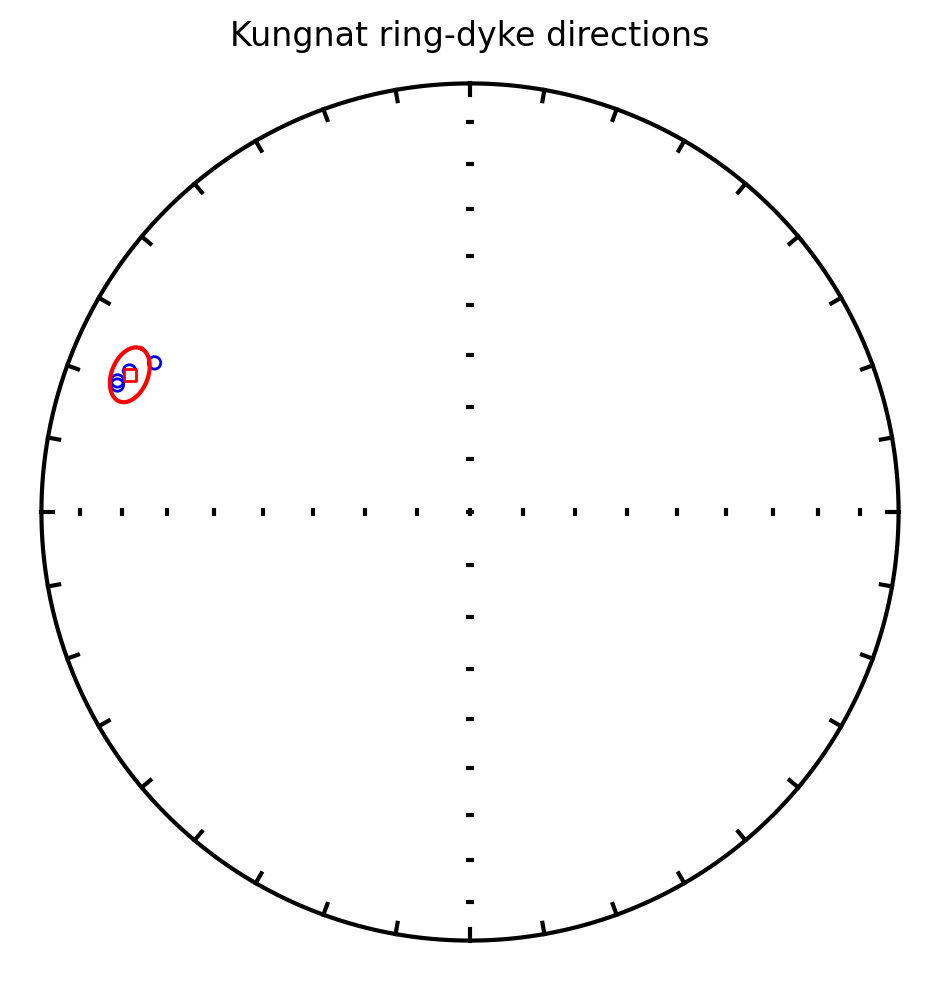

In [3]:
dir_block, dir_mean = pt.compute_mean_direction(sites, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
print('Piper & Stearn (1977) group mean direction: 292.0/-15.4, alpha95 4.3')

plon_dir, plat_dir, dp_dir, dm_dir = pmag.dia_vgp(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], study_lat, study_lon)
dir_pole = {'dec': plon_dir % 360, 'inc': plat_dir, 'dp': dp_dir, 'dm': dm_dir, 'alpha95': (dp_dir * dm_dir) ** 0.5}
print(f"direction-derived pole: {dir_pole['inc']:.1f} N / {dir_pole['dec']:.1f} E, dp/dm {dir_pole['dp']:.1f}/{dir_pole['dm']:.1f}, geometric A95 {dir_pole['alpha95']:.1f}")
print('Piper & Stearn (1977) pole: 3.4 N / 198.7 E, dp/dm 2.3/4.4, A95 3.2')

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Kungnat ring-dyke directions')
plt.show()

## Mean pole from site VGPs

The Nordic summary below reports the Fisher mean of the four site VGPs. For this compact high-precision data set, it is effectively identical to Piper & Stearn's direction-derived pole.

Plon: 198.6  Plat: 3.4
Number of directions in mean (n): 4
Angular radius of 95% confidence (A_95): 3.3
Precision parameter (k) estimate: 769.9
Piper & Stearn (1977) / Evans et al. (2021): 3.4 N / 198.7 E, A95 3.2


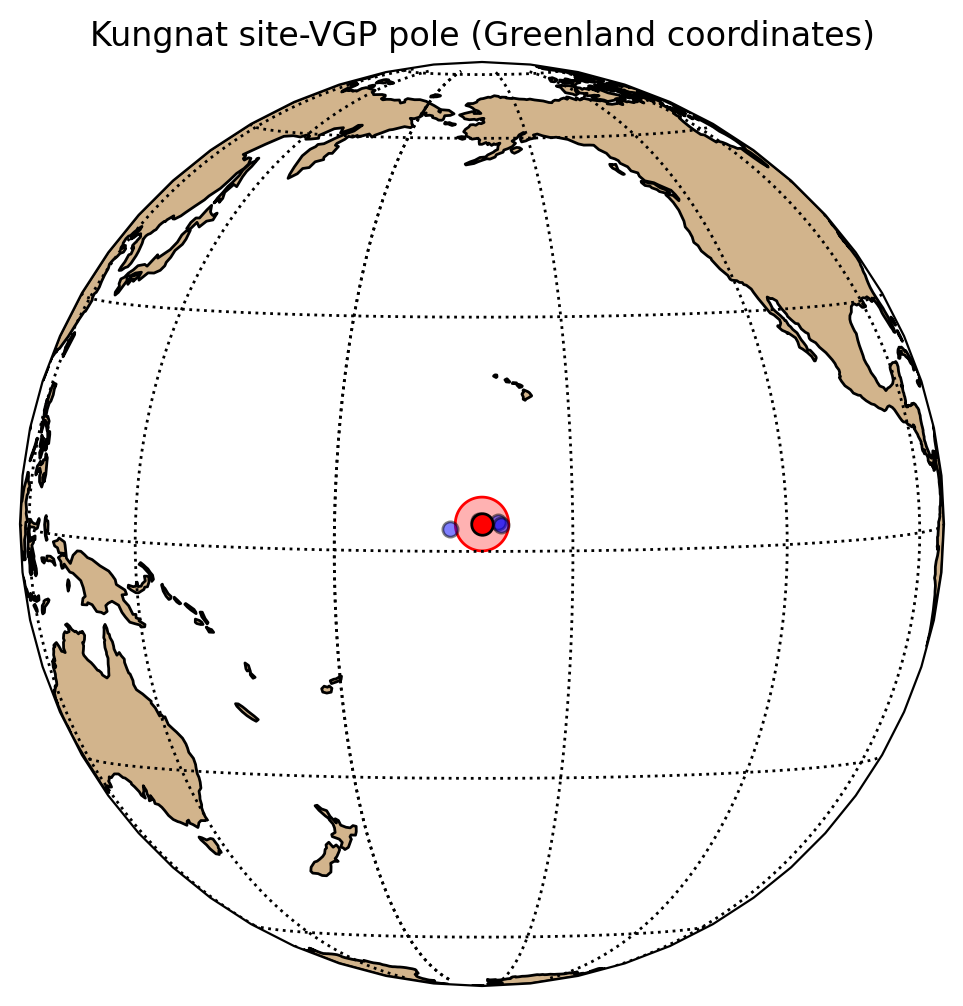

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('Piper & Stearn (1977) / Evans et al. (2021): 3.4 N / 198.7 E, A95 3.2')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Kungnat site-VGP pole (Greenland coordinates)')
plt.show()

## Paleosecular variation and R2

In [5]:
r2_result = pt.assess_R2(sites, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 18 samples (>= 25): FAIL
        K = 769.9 (10-70): FAIL
        B = 4 sites (>= 8): FAIL
        min 3 samples/site (>= 3): PASS
        A95 = 3.3 in Deenen envelope [6.9, 34.2]: FAIL
  => R2 (from sub-criterion c) = 0

A_95 of 3.3 is too small for Deenen criteria of 6.9 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

## Laurentia reference frame

unrotated (present-day Greenland frame): 3.4 N / 198.6 E, A95 3.3
rotated into the Laurentia frame:        7.4 N / 186.2 E, A95 3.3


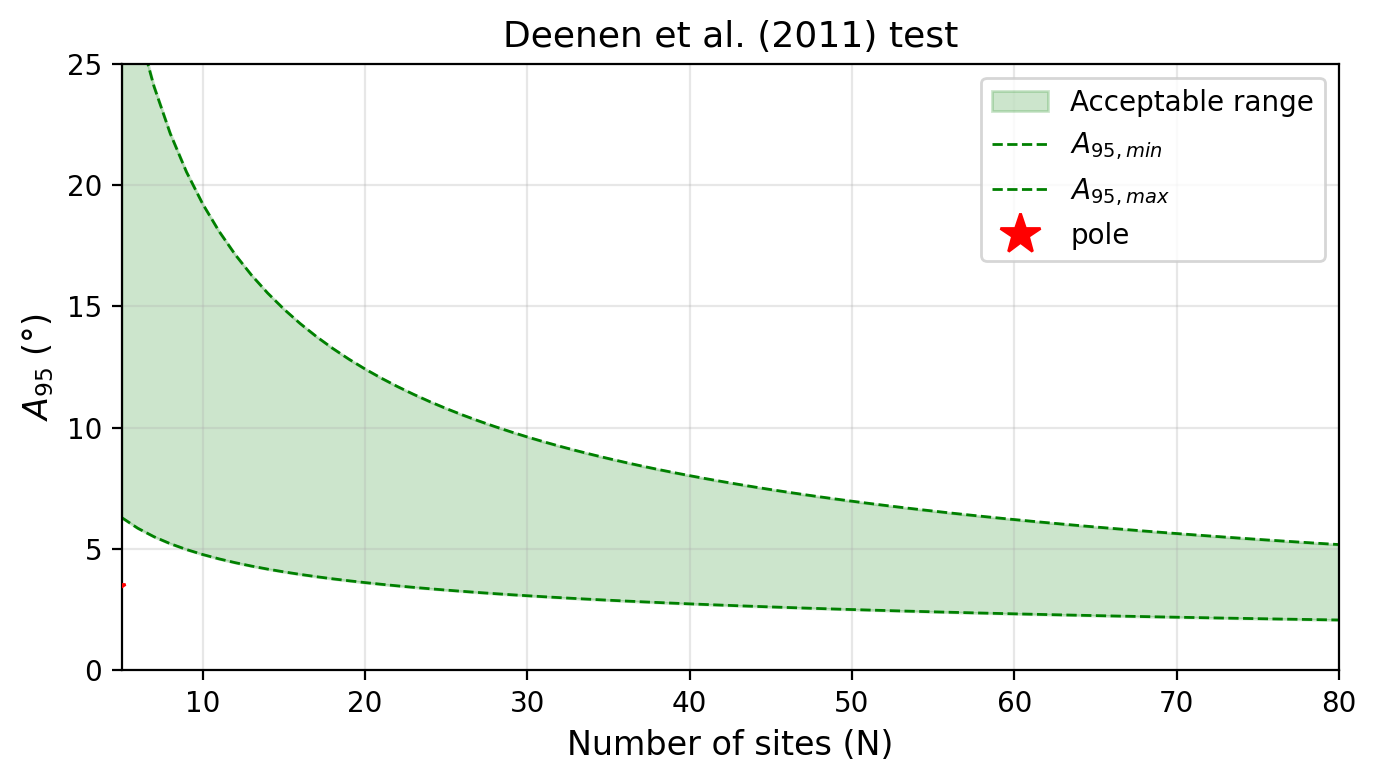

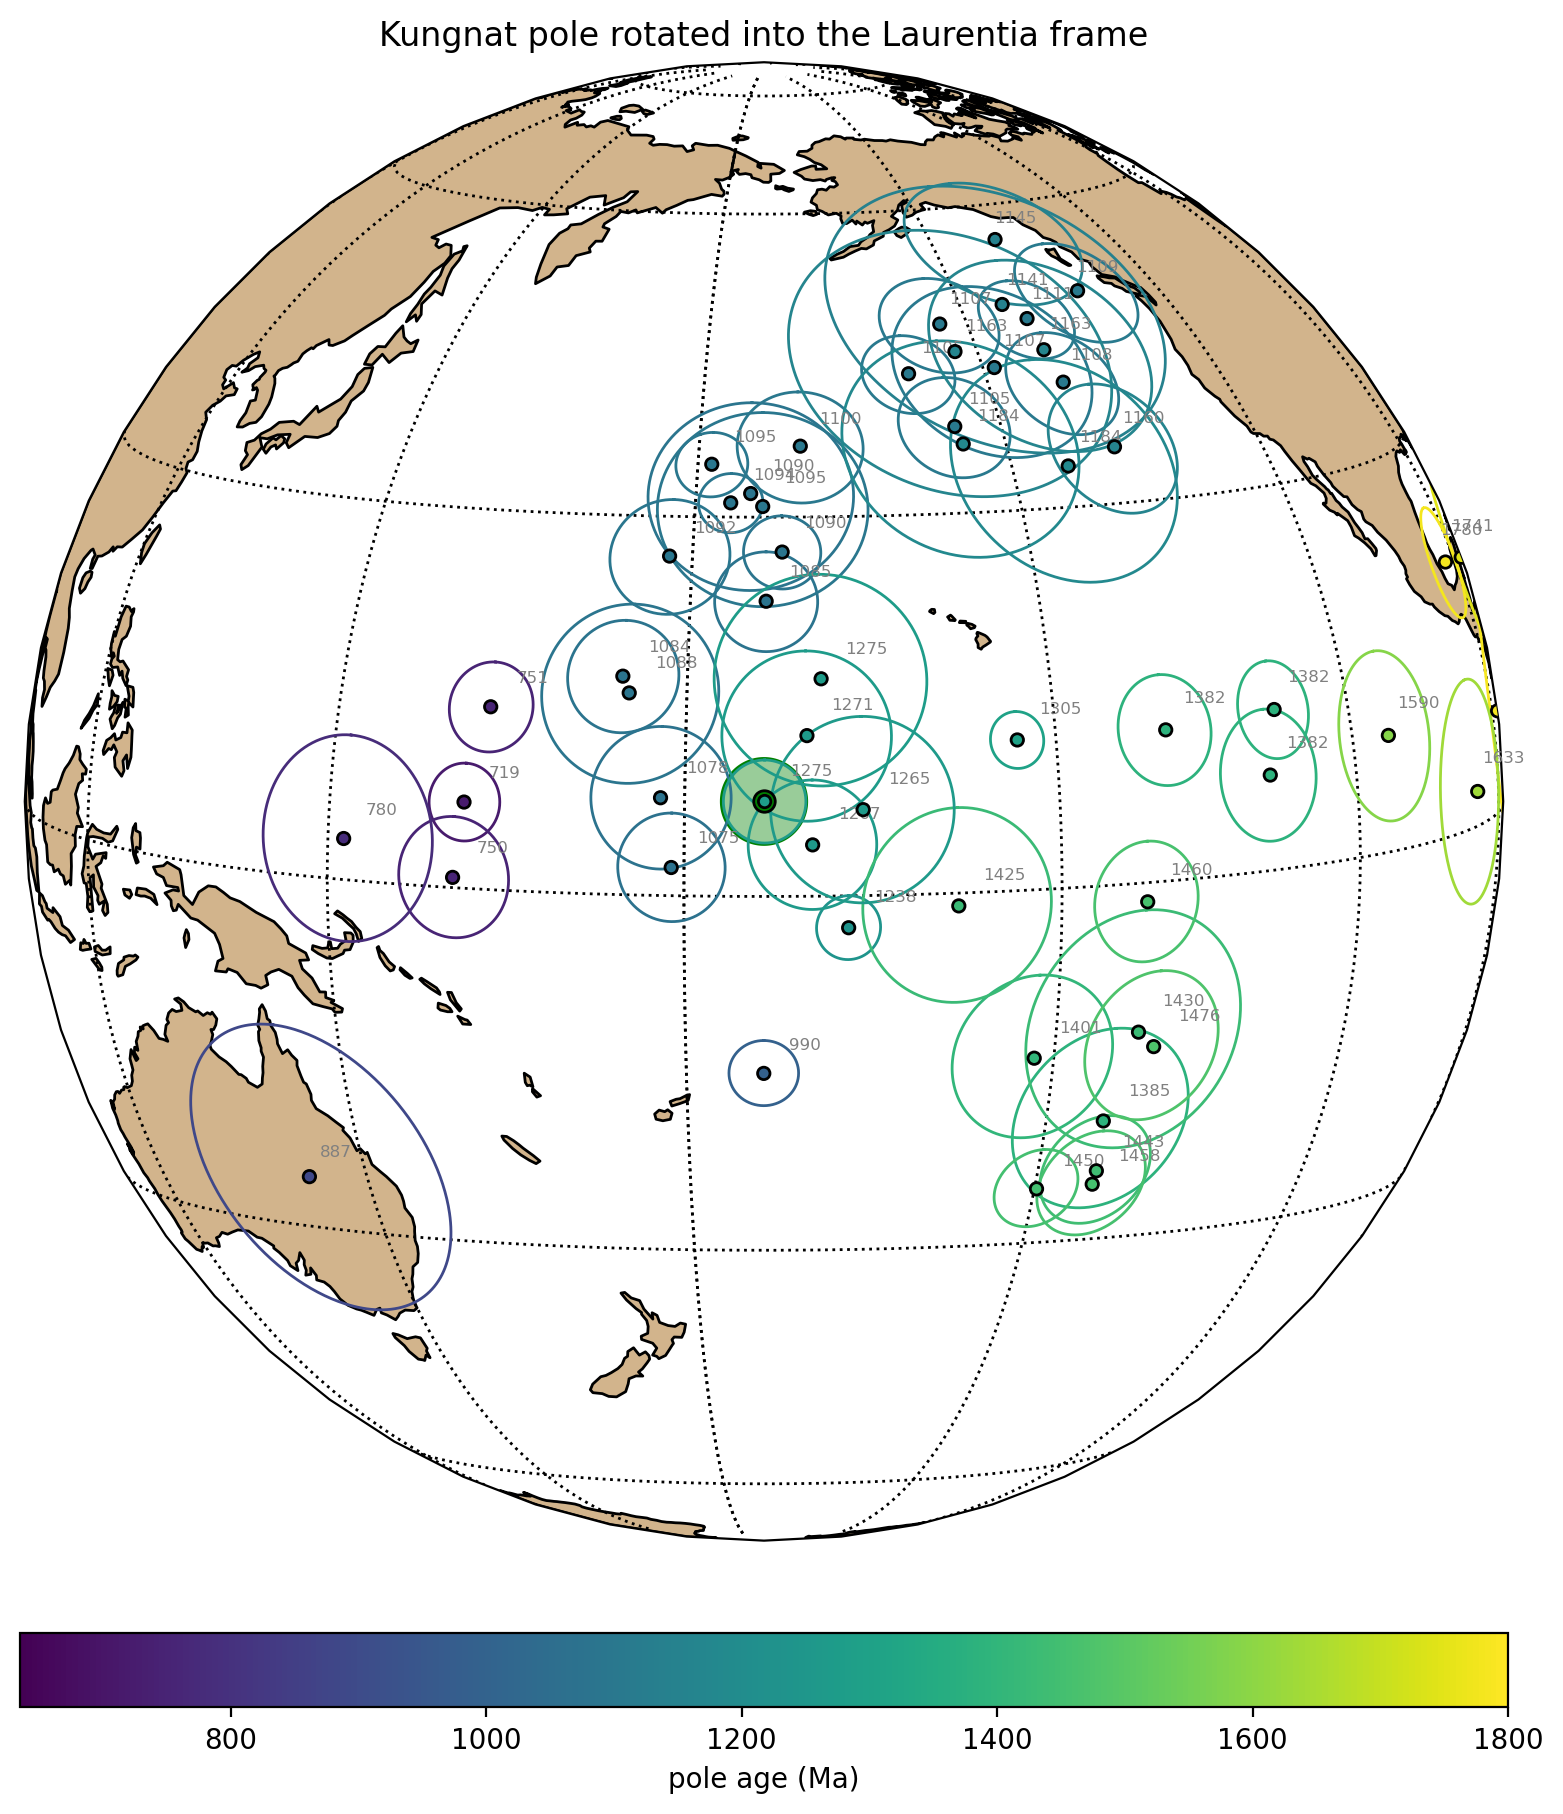

In [6]:
EULER_GREENLAND = pt.TERRANE_EULER_POLES['Laurentia-Greenland']
_rlat, _rlon = pmag.pt_rot(EULER_GREENLAND, [pole_mean['inc']], [pole_mean['dec']])
pole_rot = {'inc': _rlat[0], 'dec': _rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}")
print(f"rotated into the Laurentia frame:        {pole_rot['inc']:.1f} N / {pole_rot['dec']:.1f} E, A95 {pole_rot['alpha95']:.1f}")

ax = pt.plot_apwp_context(Laurentia_poles, pole_rot['inc'], pole_rot['dec'],
                          pole_rot['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rot['dec'],
                          central_latitude=pole_rot['inc'])
plt.title('Kungnat pole rotated into the Laurentia frame')
plt.show()

## Comparison with younger Laurentia poles

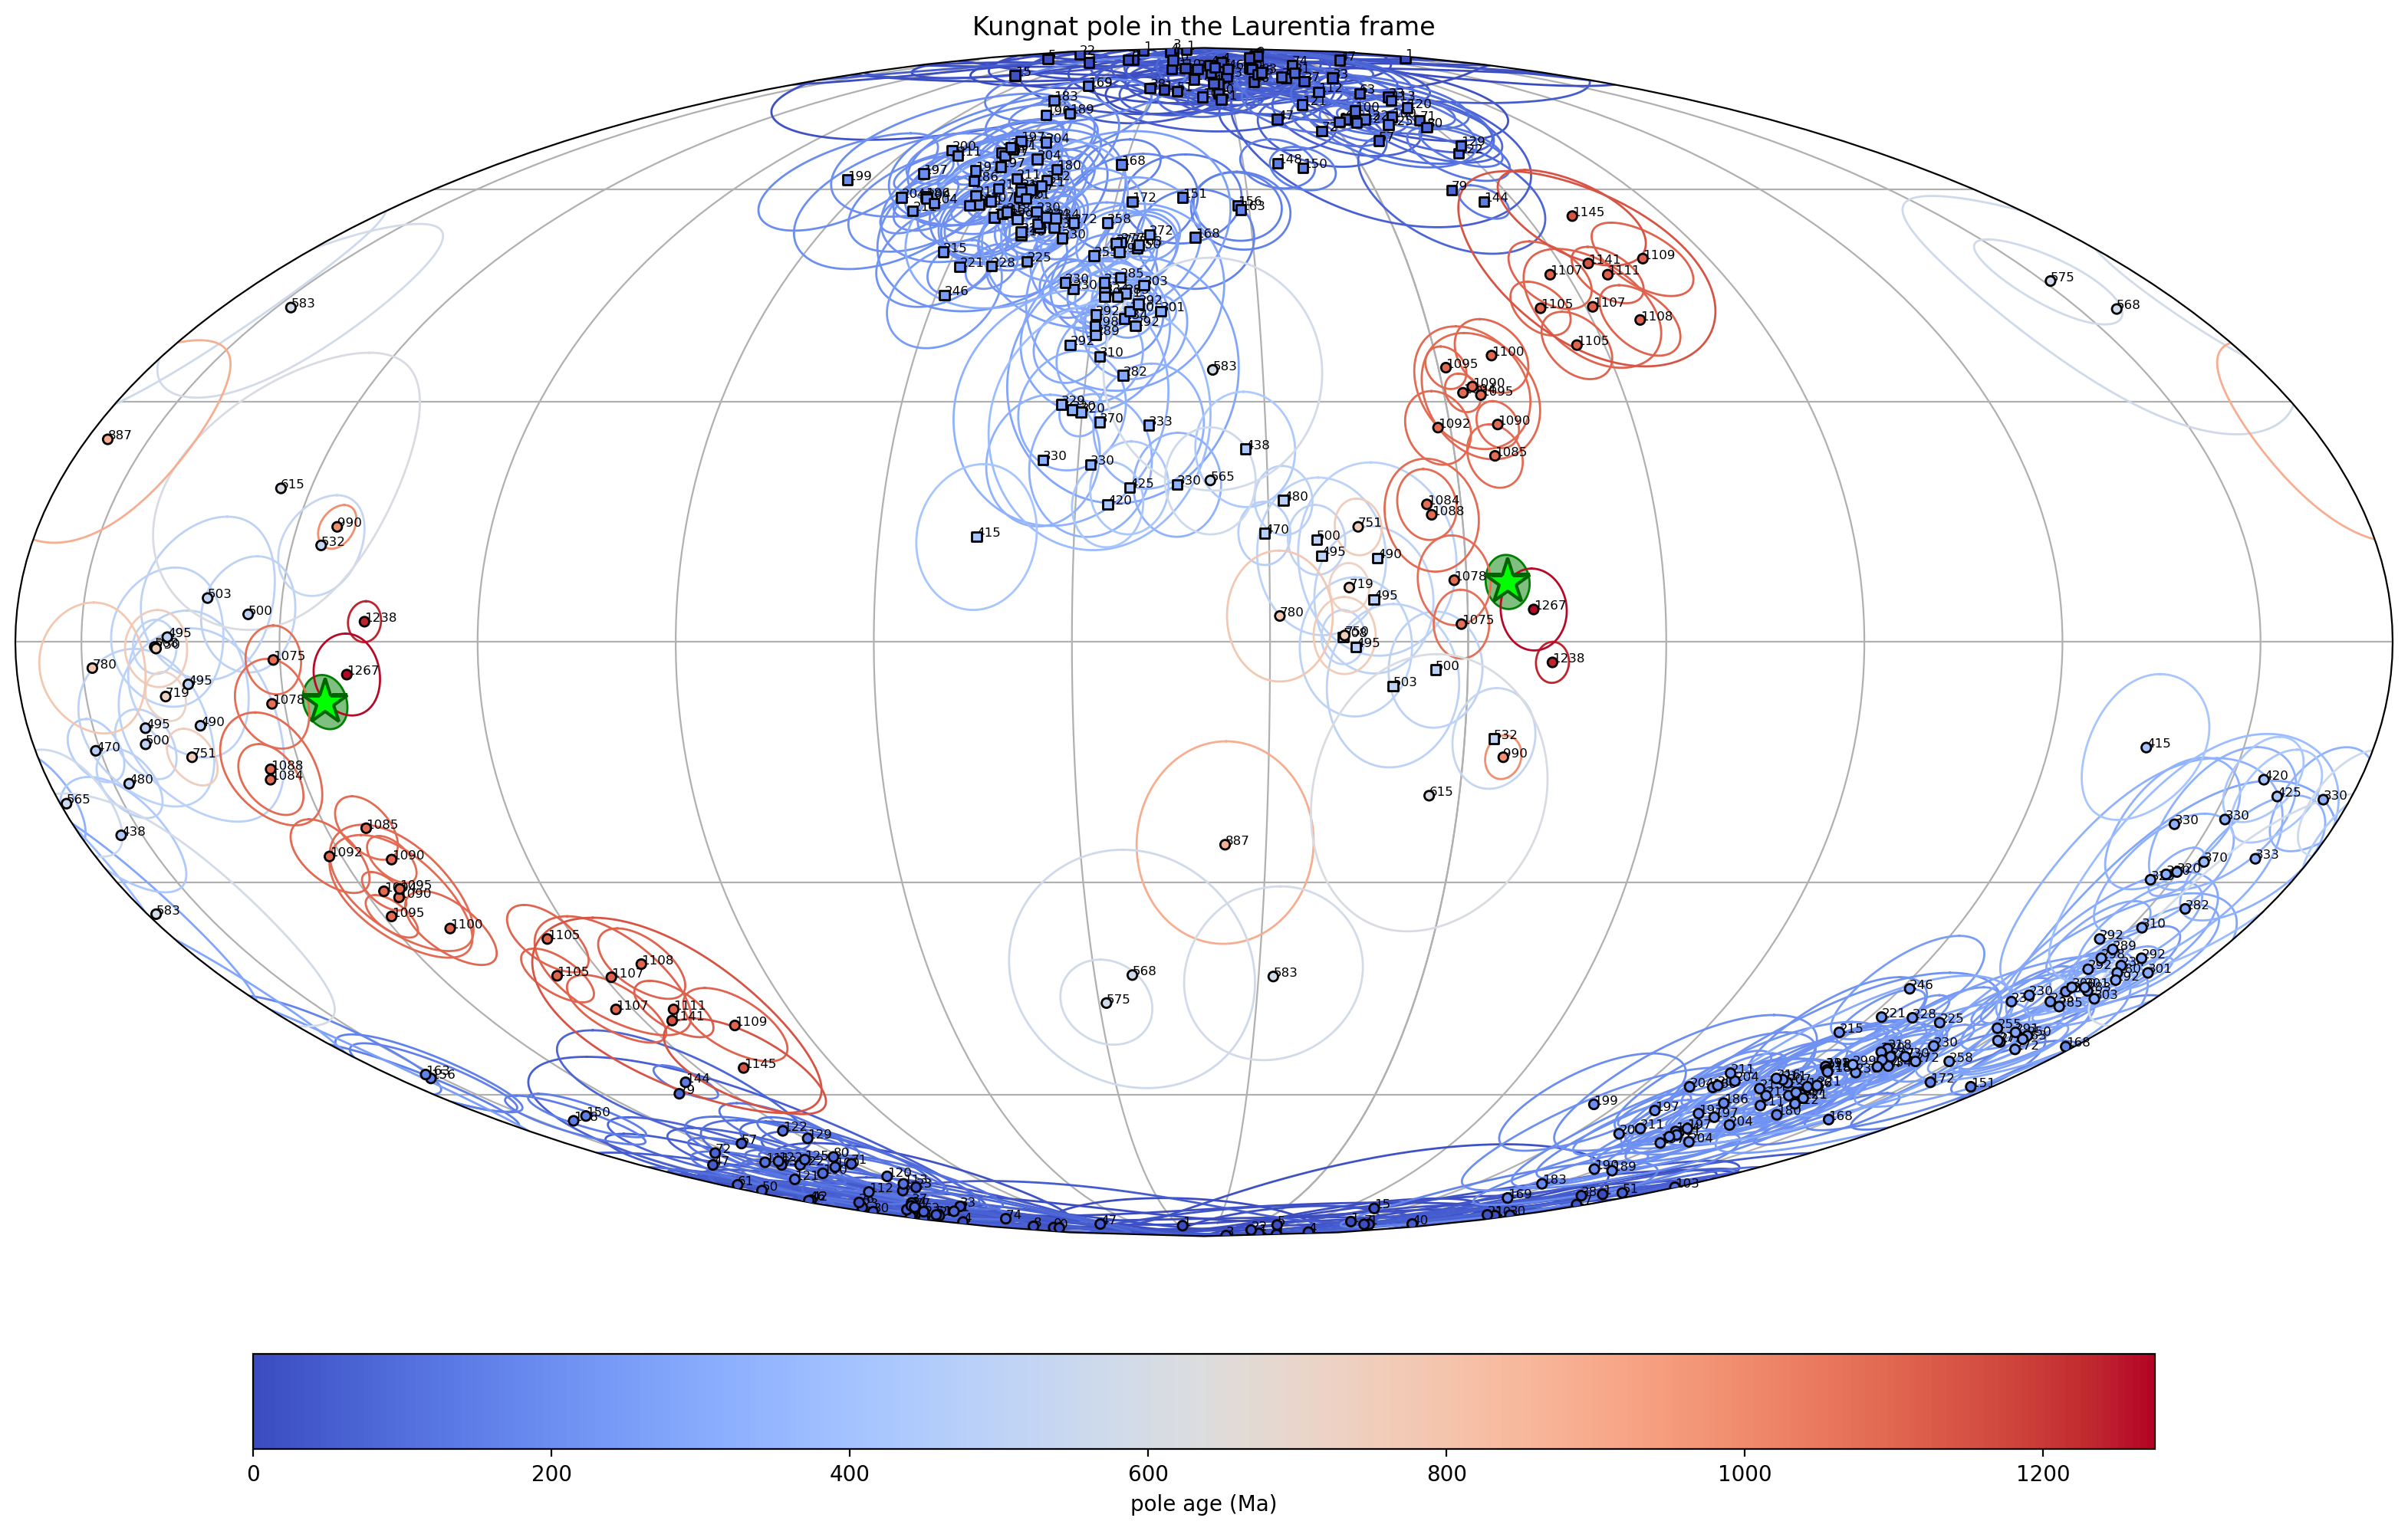

In [7]:
pt.plot_pole_overlap('Kungnat Ring Dyke', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rot['inc'], pole_plon=pole_rot['dec'],
                     pole_A95=pole_rot['alpha95'], pole_age=1275, show=False)
plt.title('Kungnat pole in the Laurentia frame')
plt.show()

## Nordic workshop summary

The exported pole is the recalculated site-VGP Fisher mean in present-day Greenland coordinates. The comment records the near-exact match to the published direction-derived pole.

In [8]:
summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Kungnat Ring Dyke',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization; Kungnat ring dyke site means (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=int(r2_result['R2']), R3=1, R4='', R5=1, R6=0, R7=1, Grade='B',
    nominal_age=1275, lomagage=1273, himagage=1277,
    REF_method='1275.2 +/- 1.8 Ma U-Pb date (2 sigma) from Upton (2003).',
    POLE_AUTHORS='Piper, J.D.A., Stearn, J.E.F.',
    YEAR=1977,
    JOURNAL='Physics Earth Planet. Int.',
    VOLUME='14',
    VPAGES='345-358',
    TITLE='Palaeomagnetism of the dyke swarms of the Gardar Igneous Province, South Greenland',
    COMMENT='Recalculated from the four Piper & Stearn (1977) Table I Kungnat site means. Site VGP Fisher pole is %.1f N / %.1f E, A95 %.1f; the direction-derived pole is %.1f N / %.1f E, dp/dm %.1f/%.1f, matching the published 3.4 N / 198.7 E pole.' % (pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], dir_pole['inc'], dir_pole['dec'], dir_pole['dp'], dir_pole['dm'])
)
pt.save_nordic_summary(summary, '1275_Kungnat')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Kungnat Ring Dyke,,Characteristic remanent magnetization; Kungnat...,,0,61.2,311.7,4,18,...,1277,1275.2 +/- 1.8 Ma U-Pb date (2 sigma) from Upt...,Kungnat Ring Dyke,"Piper, J.D.A., Stearn, J.E.F.",1977,Physics Earth Planet. Int.,14,345-358,Palaeomagnetism of the dyke swarms of the Gard...,Recalculated from the four Piper & Stearn (197...
